# Data Preparation

In [1]:
import pandas as pd

walmart_retail_data = "walmart_retail.csv"
us_zip_data = "uszips.csv"

df_walmart_retail = pd.read_csv(walmart_retail_data, sep = ',', decimal = '.', header = 0)
df_us_zip = pd.read_csv(us_zip_data, sep = ',', decimal = '.', header = 0)

In [2]:
df_walmart_retail.head()

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Profit,Region,Row ID,Sales,Ship Date,Ship Mode,Shipping Cost,State,Unit Price,Zip Code
0,McKeesport,NaN,Jessica Myrick,Small Business,0.10,1,1/1/2012,28774,High,32,...,-111.80,East,4031,180.36,1/2/2012,Regular Air,4.69,Pennsylvania,5.98,15131
1,Bowie,NaN,Matt Collister,Home Office,0.08,1,1/1/2012,13729,Not Specified,9,...,-342.91,East,1914,872.48,1/3/2012,Express Air,35.00,Maryland,95.99,20715
2,Napa,NaN,Alan Schoenberger,Corporate,0.00,1,1/2/2012,37537,Low,4,...,-193.08,West,5272,1239.06,1/2/2012,Delivery Truck,48.80,California,291.73,94559
3,Montebello,NaN,Elizabeth Moffitt,Consumer,0.08,1,1/2/2012,44069,Critical,43,...,247.79,West,6225,614.80,1/2/2012,Regular Air,1.97,California,15.04,90640
4,Napa,NaN,Alan Schoenberger,Corporate,0.07,1,1/2/2012,37537,Low,43,...,-1049.85,West,5273,4083.19,1/4/2012,Delivery Truck,45.00,California,100.98,94559


In [3]:
df_us_zip.head()

,zip,lat,lng,city,state_id,state_name,zcta,parent_zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
0,601,18.18027,-66.75266,Adjuntas,PR,Puerto Rico,True,NaN,16669.0,99.9,72001,Adjuntas,"{""72001"": 98.74, ""72141"": 1.26}",Adjuntas|Utuado,72001|72141,False,False,America/Puerto_Rico
1,602,18.36075,-67.17541,Aguada,PR,Puerto Rico,True,NaN,37233.0,474.0,72003,Aguada,"{""72003"": 100}",Aguada,72003,False,False,America/Puerto_Rico
2,603,18.45744,-67.12225,Aguadilla,PR,Puerto Rico,True,NaN,48448.0,544.6,72005,Aguadilla,"{""72005"": 99.76, ""72099"": 0.24}",Aguadilla|Moca,72005|72099,False,False,America/Puerto_Rico
3,606,18.16585,-66.93716,Maricao,PR,Puerto Rico,True,NaN,5163.0,45.0,72093,Maricao,"{""72093"": 82.26, ""72153"": 11.67, ""72121"": 6.06}",Maricao|Yauco|Sabana Grande,72093|72153|72121,False,False,America/Puerto_Rico
4,610,18.29110,-67.12243,Anasco,PR,Puerto Rico,True,NaN,25357.0,263.8,72011,Añasco,"{""72011"": 96.8, ""72099"": 2.83, ""72083"": 0.37}",Añasco|Moca|Las Marías,72011|72099|72083,False,False,America/Puerto_Rico


In [4]:
df_walmart_retail.dtypes

City                     object
Customer Age            float64
Customer Name            object
Customer Segment         object
Discount                float64
Number of Records         int64
Order Date               object
Order ID                  int64
Order Priority           object
Order Quantity            int64
Product Base Margin     float64
Product Category         object
Product Container        object
Product Name             object
Product Sub-Category     object
Profit                  float64
Region                   object
Row ID                    int64
Sales                   float64
Ship Date                object
Ship Mode                object
Shipping Cost           float64
State                    object
Unit Price              float64
Zip Code                  int64
dtype: object

In [5]:
df_us_zip.dtypes

zip                   int64
lat                 float64
lng                 float64
city                 object
state_id             object
state_name           object
zcta                   bool
parent_zcta         float64
population          float64
density             float64
county_fips           int64
county_name          object
county_weights       object
county_names_all     object
county_fips_all      object
imprecise              bool
military               bool
timezone             object
dtype: object

In [6]:
df_walmart_retail.shape

(8399, 25)

In [7]:
df_us_zip.shape

(33782, 18)

In [8]:
zip_length = df_walmart_retail["Zip Code"].astype(int).astype(str).str.len()

print(zip_length.value_counts().sort_index())

Zip Code
4     672
5    7727
Name: count, dtype: int64


In [9]:
zip_length = df_walmart_retail["Zip Code"].astype(int).astype(str).str.len()

print(zip_length.value_counts().sort_index())

Zip Code
4     672
5    7727
Name: count, dtype: int64


In [10]:
# Pad back to 5 digits so the zip code matches the reference file

df_walmart_retail["zip5"] = df_walmart_retail["Zip Code"].astype(int).astype(str).str.zfill(5)

df_walmart_retail[["City", "State", "Zip Code", "zip5"]].head()

,City,State,Zip Code,zip5
0,McKeesport,Pennsylvania,15131,15131
1,Bowie,Maryland,20715,20715
2,Napa,California,94559,94559
3,Montebello,California,90640,90640
4,Napa,California,94559,94559


In [11]:
#Zip on us zip was 5 digit, however was forcely converted into integer so the first few 0s on the digits were gone,
#force them back to str and 5 digit

df_us_zip["zip"] = df_us_zip["zip"].astype(str).str.zfill(5)

In [12]:
#Merge the datasets first before cleaning - less cleaning work

zip_columns = ["zip", "population", "density", "county_name", "state_id"]

df_merged = df_walmart_retail.merge(
    df_us_zip[zip_columns],
    left_on = "zip5",
    right_on = "zip",
    how = "left"
)

print("Rows before merge:", df_walmart_retail.shape[0])
print("Rows after merge:", df_merged.shape[0])

Rows before merge: 8399
Rows after merge: 8399


In [13]:
df_merged.isnull().sum()

City                      0
Customer Age            903
Customer Name             0
Customer Segment          0
Discount                  0
Number of Records         0
Order Date                0
Order ID                  0
Order Priority            0
Order Quantity            0
Product Base Margin      63
Product Category          0
Product Container         0
Product Name              0
Product Sub-Category      0
Profit                    0
Region                    0
Row ID                    0
Sales                     0
Ship Date                 0
Ship Mode                 0
Shipping Cost             0
State                     0
Unit Price                0
Zip Code                  0
zip5                      0
zip                      83
population               83
density                  83
county_name              83
state_id                 83
dtype: int64

In [14]:
# Fill the unmatched rows instead of dropping them

df_merged["population"] = df_merged["population"].fillna(df_merged["population"].median())
df_merged["density"] = df_merged["density"].fillna(df_merged["density"].median())

In [15]:
df_merged.isnull().sum()

City                      0
Customer Age            903
Customer Name             0
Customer Segment          0
Discount                  0
Number of Records         0
Order Date                0
Order ID                  0
Order Priority            0
Order Quantity            0
Product Base Margin      63
Product Category          0
Product Container         0
Product Name              0
Product Sub-Category      0
Profit                    0
Region                    0
Row ID                    0
Sales                     0
Ship Date                 0
Ship Mode                 0
Shipping Cost             0
State                     0
Unit Price                0
Zip Code                  0
zip5                      0
zip                      83
population                0
density                   0
county_name              83
state_id                 83
dtype: int64

In [16]:
df_merged.shape

(8399, 31)

In [17]:
print("Minimum age:", df_merged["Customer Age"].min())
print("Maximum age:", df_merged["Customer Age"].max())

Minimum age: 41.0
Maximum age: 95.0


In [18]:
# Customer Age is dropped many missing values and range does not make sense, no one below 41
# Row ID and Number of Records are redundant

df_merged = df_merged.drop(columns=["Customer Age", "Row ID", "Number of Records"])

df_merged.shape

(8399, 28)

In [19]:
# Convert the date columns into datetime format

df_merged["Order Date"] = pd.to_datetime(df_merged["Order Date"], format="mixed")
df_merged["Ship Date"] = pd.to_datetime(df_merged["Ship Date"], format="mixed")

print("Earliest order date:", df_merged["Order Date"].min().date())
print("Latest order date:", df_merged["Order Date"].max().date())

Earliest order date: 2012-01-01
Latest order date: 2015-12-30


In [20]:
# Check for incorrect values in the numeric columns

print("Sales <= 0:", (df_merged["Sales"] <= 0).sum())
print("Order Quantity <= 0:", (df_merged["Order Quantity"] <= 0).sum())
print("Unit Price <= 0:", (df_merged["Unit Price"] <= 0).sum())

Sales <= 0: 0
Order Quantity <= 0: 0
Unit Price <= 0: 0


In [21]:
# Check duplicates

print("Duplicated rows:", df_merged.duplicated().sum())

Duplicated rows: 0


In [22]:
df_cleaned = df_merged.copy()

df_cleaned.head()

,City,Customer Name,Customer Segment,Discount,Order Date,Order ID,Order Priority,Order Quantity,Product Base Margin,Product Category,...,Shipping Cost,State,Unit Price,Zip Code,zip5,zip,population,density,county_name,state_id
0,McKeesport,Jessica Myrick,Small Business,0.10,2012-01-01,28774,High,32,0.68,Office Supplies,...,4.69,Pennsylvania,5.98,15131,15131,15131,8209.0,479.9,Allegheny,PA
1,Bowie,Matt Collister,Home Office,0.08,2012-01-01,13729,Not Specified,9,NaN,Office Supplies,...,35.00,Maryland,95.99,20715,20715,20715,26915.0,739.7,Prince George's,MD
2,Napa,Alan Schoenberger,Corporate,0.00,2012-01-02,37537,Low,4,0.56,Furniture,...,48.80,California,291.73,94559,94559,94559,27714.0,258.7,Napa,CA
3,Montebello,Elizabeth Moffitt,Consumer,0.08,2012-01-02,44069,Critical,43,0.39,Office Supplies,...,1.97,California,15.04,90640,90640,90640,61382.0,2847.7,Los Angeles,CA
4,Napa,Alan Schoenberger,Corporate,0.07,2012-01-02,37537,Low,43,0.69,Furniture,...,45.00,California,100.98,94559,94559,94559,27714.0,258.7,Napa,CA


# Data Exploration

Average orders per customer: 6.94
Median orders per customer: 6.0
Maximum orders per customer: 26
Customers with more than one order: 784


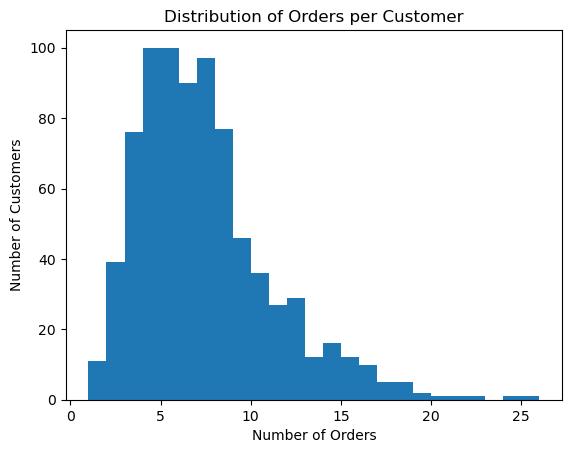

In [23]:
import matplotlib.pyplot as plt

# Orders per customer

orders_per_customer = df_cleaned.groupby("Customer Name")["Order ID"].nunique()

print("Average orders per customer:", round(orders_per_customer.mean(), 2))
print("Median orders per customer:", orders_per_customer.median())
print("Maximum orders per customer:", orders_per_customer.max())
print("Customers with more than one order:", (orders_per_customer > 1).sum())

orders_per_customer.plot(kind="hist", bins=25)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

Product Category
Office Supplies    3752762.100
Furniture          5178590.542
Technology         5984248.182
Name: Sales, dtype: float64

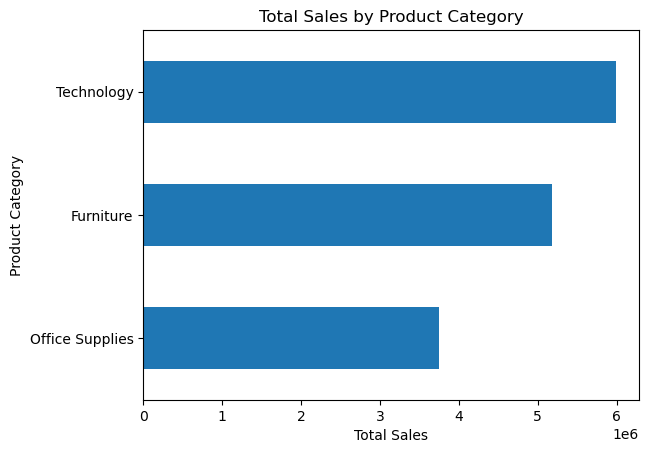

In [24]:
# Sales by product category

sales_per_category = df_cleaned.groupby("Product Category")["Sales"].sum().sort_values()

display(sales_per_category)

sales_per_category.plot(kind="barh")

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.show()

In [25]:
# Split density into four groups to see if location relates to spending

df_cleaned["DensityGroup"] = pd.qcut(
    df_cleaned["density"],
    q = 4,
    labels = ["Rural", "Suburban", "Urban", "Dense Urban"])

density_summary = df_cleaned.groupby("DensityGroup", observed=True).agg(
    NumberOfOrders = ("Order ID", "nunique"),
    AvgSales = ("Sales", "mean"),
    AvgProfit = ("Profit", "mean"),).round(2)

display(density_summary)

,NumberOfOrders,AvgSales,AvgProfit
DensityGroup,,,
Rural,1505,1789.81,187.15
Suburban,1530,1814.19,190.58
Urban,1465,1684.05,198.34
Dense Urban,1510,1813.08,148.85


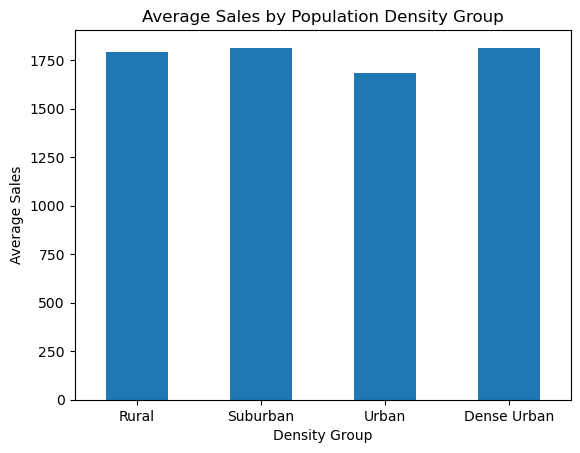

In [26]:
density_summary["AvgSales"].plot(kind="bar")

plt.title("Average Sales by Population Density Group")
plt.xlabel("Density Group")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

# Data Modelling

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

random_state = 29

# The models work at customer level, so the orders are summarised into one
# row per customer using RFM: how recently they bought, how often, and how much.

snapshot_date = df_cleaned["Order Date"].max() + pd.Timedelta(days=1)

customer_rfm = df_cleaned.groupby("Customer Name").agg(
    Recency = ("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Order ID", "nunique"),
    Monetary = ("Sales", "sum"))

print("Snapshot date:", snapshot_date.date())
print("Customers:", len(customer_rfm))

customer_rfm.head()

Snapshot date: 2015-12-31
Customers: 795


,Recency,Frequency,Monetary
Customer Name,,,
Aaron Bergman,582,5,11630.5900
Aaron Hawkins,367,9,27690.7255
Aaron Smayling,346,8,8835.3235
Adam Bellavance,90,8,11577.5800
Adam Hart,20,18,26114.2645


In [28]:
customer_rfm.describe().round(2)

,Recency,Frequency,Monetary
count,795.00,795.00,795.00
mean,233.62,6.94,18761.76
std,231.01,3.75,15973.74
min,1.00,1.00,85.72
25%,69.00,4.00,7364.20
50%,156.00,6.00,15287.67
75%,309.50,9.00,25401.01
max,1431.00,26.00,117124.44


In [29]:
# Standardised so monetary would not dominate

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(customer_rfm[["Recency", "Frequency", "Monetary"]])

print("Shape of the scaled feature matrix:", rfm_scaled.shape)

Shape of the scaled feature matrix: (795, 3)


## Machine Learning 1: K-Means

In [30]:
k_values = range(2, 9)

inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels_test = kmeans_test.fit_predict(rfm_scaled)

    inertia_scores.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels_test))

k_comparison = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette": silhouette_scores,}).round(4)

display(k_comparison)

,k,Inertia,Silhouette
0,2,1479.9110,0.3651
1,3,985.3916,0.3882
2,4,771.7531,0.3351
3,5,670.1828,0.2975
4,6,571.1005,0.3006
5,7,507.7139,0.2826
6,8,464.7206,0.2920


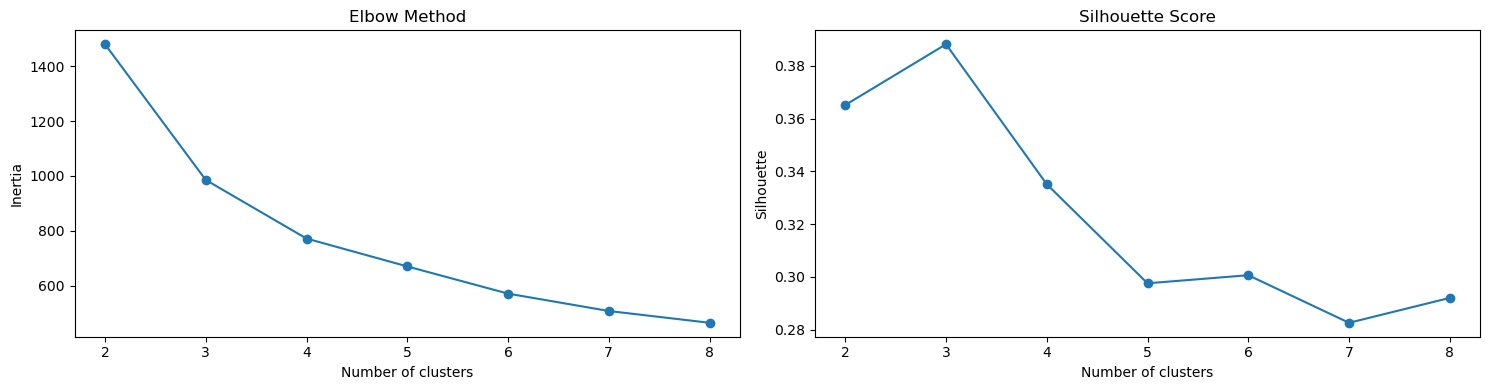

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(list(k_values), inertia_scores, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [32]:
number_of_clusters = 3

kmeans_model = KMeans(
    n_clusters = number_of_clusters,
    random_state = random_state)

customer_rfm["KMeansCluster"] = kmeans_model.fit_predict(rfm_scaled)

print("Silhouette score:", round(silhouette_score(rfm_scaled, customer_rfm["KMeansCluster"]), 4))

customer_rfm["KMeansCluster"].value_counts().sort_index()

Silhouette score: 0.387


KMeansCluster
0    145
1    484
2    166
Name: count, dtype: int64

### Cluster Profile 

In [33]:
kmeans_profile = customer_rfm.groupby("KMeansCluster").agg(
    NumberOfCustomers = ("Recency", "size"),
    MedianRecency = ("Recency", "median"),
    MedianFrequency = ("Frequency", "median"),
    MedianMonetary = ("Monetary", "median"),
    TotalRevenue = ("Monetary", "sum")).round(0)

kmeans_profile["RevenueShare%"] = (
    100 * kmeans_profile["TotalRevenue"] / customer_rfm["Monetary"].sum()).round(1)

display(kmeans_profile)

,NumberOfCustomers,MedianRecency,MedianFrequency,MedianMonetary,TotalRevenue,RevenueShare%
KMeansCluster,,,,,,
0,145,590.0,4.0,7055.0,1283220.0,8.6
1,484,138.0,6.0,13065.0,7010208.0,47.0
2,166,74.0,12.0,35148.0,6622173.0,44.4


In [34]:
#Names assigned per cluster as per characteristic

cluster_ranking = kmeans_profile.sort_values(
    by = ["MedianFrequency", "MedianMonetary"],
    ascending = False).index.tolist()

segment_labels = {
    cluster_ranking[0]: "Frequent Buyers",
    cluster_ranking[1]: "Mid-frequent Buyers",
    cluster_ranking[2]: "Low-inactive Customers"}

customer_rfm["SegmentName"] = customer_rfm["KMeansCluster"].map(segment_labels)

segment_summary = customer_rfm.groupby("SegmentName").agg(
    Customers = ("Recency", "size"),
    MedianRecency = ("Recency", "median"),
    MedianFrequency = ("Frequency", "median"),
    MedianMonetary = ("Monetary", "median"),
    TotalRevenue = ("Monetary", "sum")).round(0)

segment_summary["RevenueShare%"] = (
    100 * segment_summary["TotalRevenue"] / customer_rfm["Monetary"].sum()).round(1)

segment_summary = segment_summary.sort_values(by="MedianMonetary", ascending=False)

display(segment_summary)

,Customers,MedianRecency,MedianFrequency,MedianMonetary,TotalRevenue,RevenueShare%
SegmentName,,,,,,
Frequent Buyers,166,74.0,12.0,35148.0,6622173.0,44.4
Mid-frequent Buyers,484,138.0,6.0,13065.0,7010208.0,47.0
Low-inactive Customers,145,590.0,4.0,7055.0,1283220.0,8.6


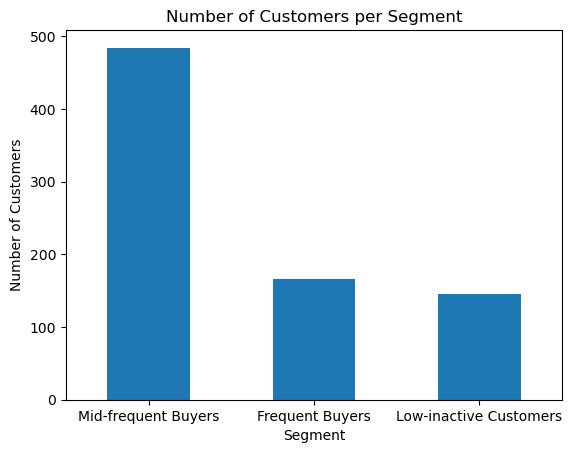

In [35]:
customer_rfm["SegmentName"].value_counts().plot(kind="bar")

plt.title("Number of Customers per Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## Machine Learning 2: Decision Tree

The K-Means segments are useful but they can only be calculated once a customer
has a full purchase history. The question here is whether the same segment can
be predicted from how a customer shops instead, which could be applied earlier.

A Decision Tree is used for this. It splits the data one feature at a time,
choosing the split that best separates the classes, and the result can be read
as a set of rules (Breiman et al., 1984).

Importantly, the features used here are different from the ones used to build
the segments. If Recency, Frequency and Monetary were used again the tree would
simply be reversing the clustering, which would not prove anything.

In [36]:
# The Decision Tree predicts the segment using different features from the ones
# used to build it. If Recency, Frequency and Monetary were reused the tree
# would just be reversing the clustering.

customer_behaviour = df_cleaned.groupby("Customer Name").agg(
    AvgDiscount = ("Discount", "mean"),
    AvgOrderQuantity = ("Order Quantity", "mean"),
    AvgUnitPrice = ("Unit Price", "mean"),
    NumberOfSubCategories = ("Product Sub-Category", "nunique"),
    MedianDensity = ("density", "median"),
    CustomerSegment = ("Customer Segment", "first"),
    Region = ("Region", "first"),
    MainShipMode = ("Ship Mode", lambda x: x.mode()[0]),
    MainCategory = ("Product Category", lambda x: x.mode()[0]))

model_data = customer_behaviour.join(customer_rfm["SegmentName"])

model_data.head()

,AvgDiscount,AvgOrderQuantity,AvgUnitPrice,NumberOfSubCategories,MedianDensity,CustomerSegment,Region,MainShipMode,MainCategory,SegmentName
Customer Name,,,,,,,,,,
Aaron Bergman,0.032857,24.000000,57.217143,6,175.2,Corporate,West,Express Air,Office Supplies,Low-inactive Customers
Aaron Hawkins,0.056667,30.833333,97.595833,10,3439.3,Home Office,East,Regular Air,Office Supplies,Mid-frequent Buyers
Aaron Smayling,0.042857,21.642857,20.597857,8,894.0,Small Business,East,Regular Air,Office Supplies,Mid-frequent Buyers
Adam Bellavance,0.045000,27.750000,28.623333,11,94.1,Small Business,West,Regular Air,Office Supplies,Mid-frequent Buyers
Adam Hart,0.054444,18.740741,48.752593,9,1651.2,Corporate,West,Regular Air,Office Supplies,Frequent Buyers


In [37]:
X = pd.get_dummies(model_data.drop(columns="SegmentName"), drop_first=True)
y = model_data["SegmentName"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.25,
    random_state = random_state,
    stratify = y)

print("Features after encoding:", X.shape[1])
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Features after encoding: 15
Training rows: 596
Test rows: 199


In [38]:
# A tree with no depth limit will memorise the training data, so different
# depths are tested to find where the test accuracy stops improving

depth_values = [2, 3, 4, 5, 6, 8, None]

train_accuracy = []
test_accuracy = []

for depth in depth_values:
    tree_test = DecisionTreeClassifier(
        max_depth = depth,
        min_samples_leaf = 10,
        random_state = random_state
    )
    tree_test.fit(X_train, y_train)

    train_accuracy.append(accuracy_score(y_train, tree_test.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, tree_test.predict(X_test)))

depth_comparison = pd.DataFrame({
    "MaxDepth": [str(d) for d in depth_values],
    "TrainAccuracy": train_accuracy,
    "TestAccuracy": test_accuracy}).round(4)

display(depth_comparison)

,MaxDepth,TrainAccuracy,TestAccuracy
0,2,0.6997,0.6935
1,3,0.7248,0.7286
2,4,0.7299,0.7136
3,5,0.7483,0.6533
4,6,0.7718,0.6482
5,8,0.7836,0.6030
6,None,0.7903,0.6382


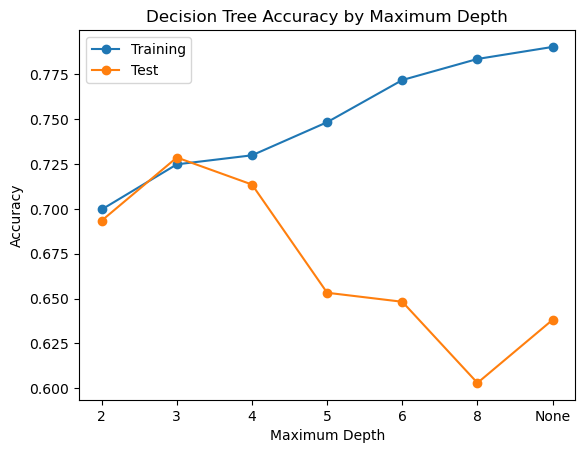

In [39]:
plt.plot(range(len(depth_values)), train_accuracy, marker="o", label="Training")
plt.plot(range(len(depth_values)), test_accuracy, marker="o", label="Test")

plt.xticks(range(len(depth_values)), [str(d) for d in depth_values])
plt.title("Decision Tree Accuracy by Maximum Depth")
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [40]:
best_depth = 3

decision_tree_model = DecisionTreeClassifier(
    max_depth = best_depth,
    min_samples_leaf = 10,
    random_state = random_state
)

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_test)

# The baseline is what you would get by always guessing the largest segment
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Test accuracy:", round(accuracy_score(y_test, tree_predictions), 4))
print("Baseline accuracy:", round(baseline_accuracy, 4))
print()
print(classification_report(y_test, tree_predictions))

Test accuracy: 0.7286
Baseline accuracy: 0.608

                        precision    recall  f1-score   support

       Frequent Buyers       0.77      0.57      0.66        42
Low-inactive Customers       0.86      0.17      0.28        36
   Mid-frequent Buyers       0.71      0.95      0.82       121

              accuracy                           0.73       199
             macro avg       0.78      0.56      0.58       199
          weighted avg       0.75      0.73      0.69       199



In [41]:
# Check the result is not just a lucky train/test split

cv_scores = cross_val_score(decision_tree_model, X, y, cv=5)

print("Cross validation scores:", cv_scores.round(4))
print("Mean:", round(cv_scores.mean(), 4))

Cross validation scores: [0.6667 0.7044 0.673  0.7296 0.7358]
Mean: 0.7019


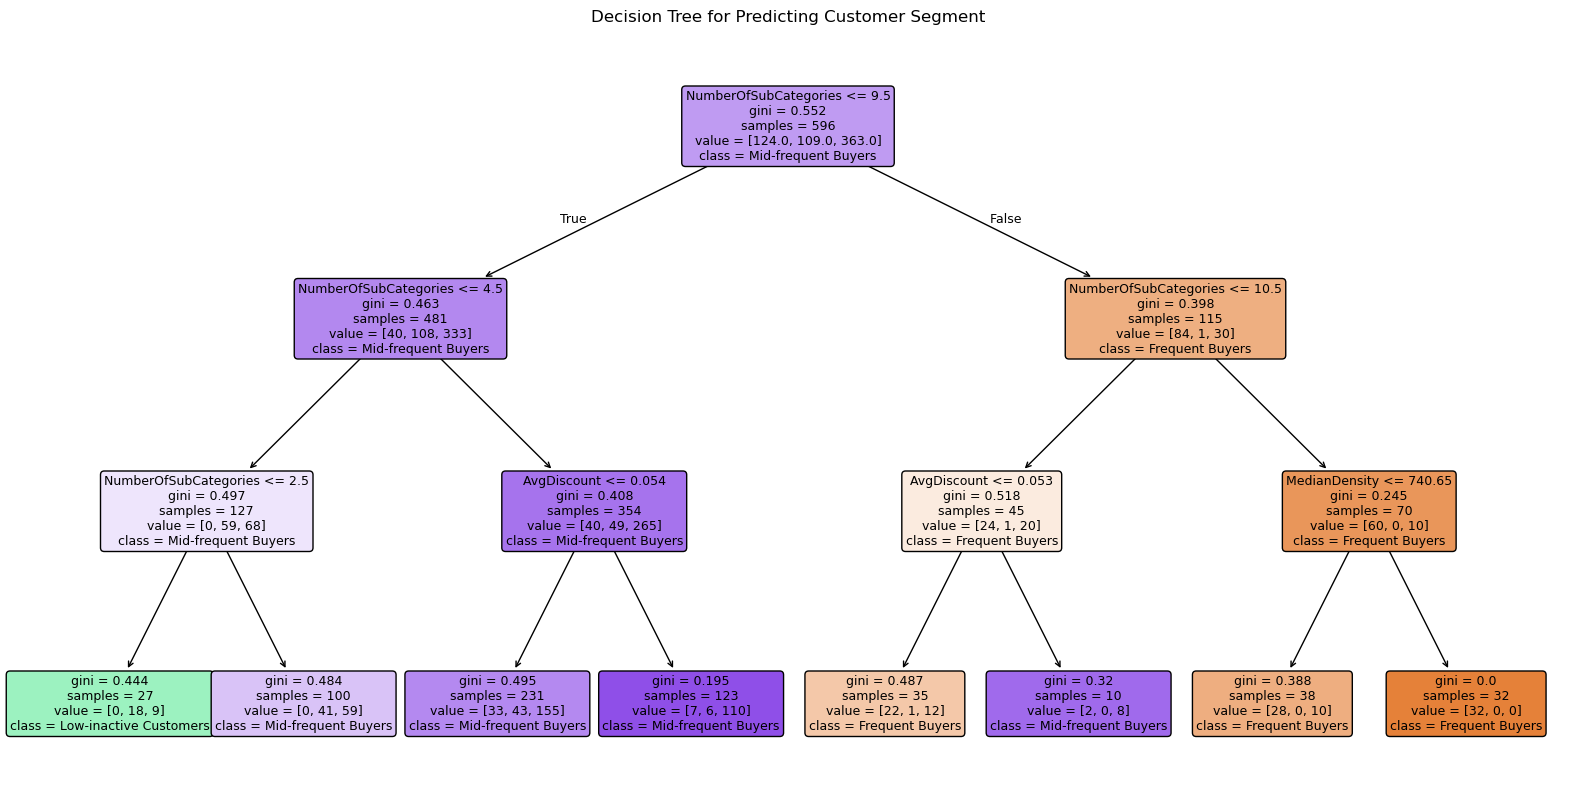

In [42]:
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names = X.columns,
    class_names = decision_tree_model.classes_,
    filled = True,
    rounded = True,
    fontsize = 9)

plt.title("Decision Tree for Predicting Customer Segment")
plt.show()

In [43]:
# Which features the tree actually used

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance = feature_importance[feature_importance["Importance"] > 0]

display(feature_importance.head(10).round(4))

,Feature,Importance
3,NumberOfSubCategories,0.8789
0,AvgDiscount,0.0959
4,MedianDensity,0.0252


### Comparing 2 models

In [44]:
# confusion matrix

comparison_table = pd.crosstab(
    y_test,
    tree_predictions,
    rownames = ["Actual Segment"],
    colnames = ["Predicted Segment"])

display(comparison_table)

Predicted Segment,Frequent Buyers,Low-inactive Customers,Mid-frequent Buyers
Actual Segment,,,
Frequent Buyers,24,0,18
Low-inactive Customers,2,6,28
Mid-frequent Buyers,5,1,115


In [45]:
#segment profile

df_with_segment = df_cleaned.merge(
    customer_rfm[["SegmentName"]],
    left_on = "Customer Name",
    right_index = True,
    how = "left")

segment_profile = df_with_segment.groupby("SegmentName").agg(
    Customers = ("Customer Name", "nunique"),
    Orders = ("Order ID", "nunique"),
    TotalProfit = ("Profit", "sum"),
    MedianDensity = ("density", "median")
).round(0)

segment_profile["ProfitPerCustomer"] = (
    segment_profile["TotalProfit"] / segment_profile["Customers"]
).round(0)

display(segment_profile)

,Customers,Orders,TotalProfit,MedianDensity,ProfitPerCustomer
SegmentName,,,,,
Frequent Buyers,166,2060,802981.0,739.0,4837.0
Low-inactive Customers,145,573,123487.0,752.0,852.0
Mid-frequent Buyers,484,2878,595301.0,739.0,1230.0
